In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix , ConfusionMatrixDisplay, classification_report
from sklearn.metrics import  roc_curve
from sklearn.tree import plot_tree
import pandas as pd
pd.set_option('display.max_columns', None)
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/notebooks/harshparsana03/security-incident/GUIDE_Train_clean_sentinel_nan.csv')

In [3]:
df.head()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,ActionGrouped,ActionGranular,EntityType,EvidenceRole,DeviceId,Sha256,IpAddress,Url,AccountSid,AccountUpn,AccountObjectId,AccountName,DeviceName,NetworkMessageId,EmailClusterId,RegistryKey,RegistryValueName,RegistryValueData,ApplicationId,ApplicationName,OAuthApplicationId,ThreatFamily,FileName,FolderPath,ResourceIdName,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04 06:05:15+00:00,7,6,InitialAccess,NaN,TruePositive,NaN,NaN,Ip,Related,98799,138268,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,635,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,66,NaN,NaN,NaN,31,6,3
1,455266534868,88,326,210035,2024-06-14 03:01:25+00:00,58,43,Exfiltration,NaN,FalsePositive,NaN,NaN,User,Impacted,98799,138268,NaN,NaN,22406.0,23032.0,22795.0,24887.0,NaN,NaN,NaN,NaN,635,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630
2,1056561957389,809,58352,712507,2024-06-13 04:52:55+00:00,423,298,InitialAccess,T1189,FalsePositive,NaN,NaN,Url,Related,98799,138268,NaN,68652.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,635,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
3,1279900258736,92,32992,774301,2024-06-10 16:39:36+00:00,2,2,CommandAndControl,NaN,BenignPositive,NaN,NaN,Url,Related,98799,138268,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,635,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,66,NaN,Suspicious,Suspicious,242,1445,10630
4,214748368522,148,4359,188041,2024-06-15 01:08:07+00:00,9,74,Execution,NaN,TruePositive,NaN,NaN,User,Impacted,98799,138268,NaN,NaN,449.0,592.0,440.0,479.0,NaN,NaN,NaN,NaN,635,860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,66,NaN,NaN,NaN,242,1445,10630


# Data Visualization

## 1) Understanding relationship between Categroical variables and target variable

In [4]:
table = pd.DataFrame()
categorical_cols = ['Category', 'EntityType', 'ActionGrouped', 'ActionGranular',
                     'EvidenceRole', 'ResourceType', 'Roles', 'AntispamDirection',
                     'SuspicionLevel', 'LastVerdict', 'MitreTechniques', 'ThreatFamily']
for col in categorical_cols:
    tab = pd.crosstab(df[col], df['IncidentGrade'])
    chi2, p, dof, expected = chi2_contingency(tab)
    corr = association(tab,method='cramer')
    row = pd.DataFrame([[col , chi2, p , corr]],columns = ['Column','Chi2','PValue','CramersV'])
    table = pd.concat([table,row], ignore_index=True)
table

,Column,Chi2,PValue,CramersV
0,Category,1.769685e+06,0.000000e+00,0.306111
1,EntityType,1.775322e+06,0.000000e+00,0.306598
2,ActionGrouped,1.884807e+02,1.123989e-39,0.141242
3,ActionGranular,4.354446e+02,6.972783e-76,0.214682
4,EvidenceRole,2.431131e+05,0.000000e+00,0.160454
5,ResourceType,2.406116e+03,0.000000e+00,0.414123
6,Roles,4.018236e+04,0.000000e+00,0.303692
7,AntispamDirection,5.517139e+02,5.565293e-114,0.039445
8,SuspicionLevel,5.248991e+01,3.999093e-12,0.006048
9,LastVerdict,2.422544e+04,0.000000e+00,0.073793


## 2) Understanding relationship between Categorical Variables

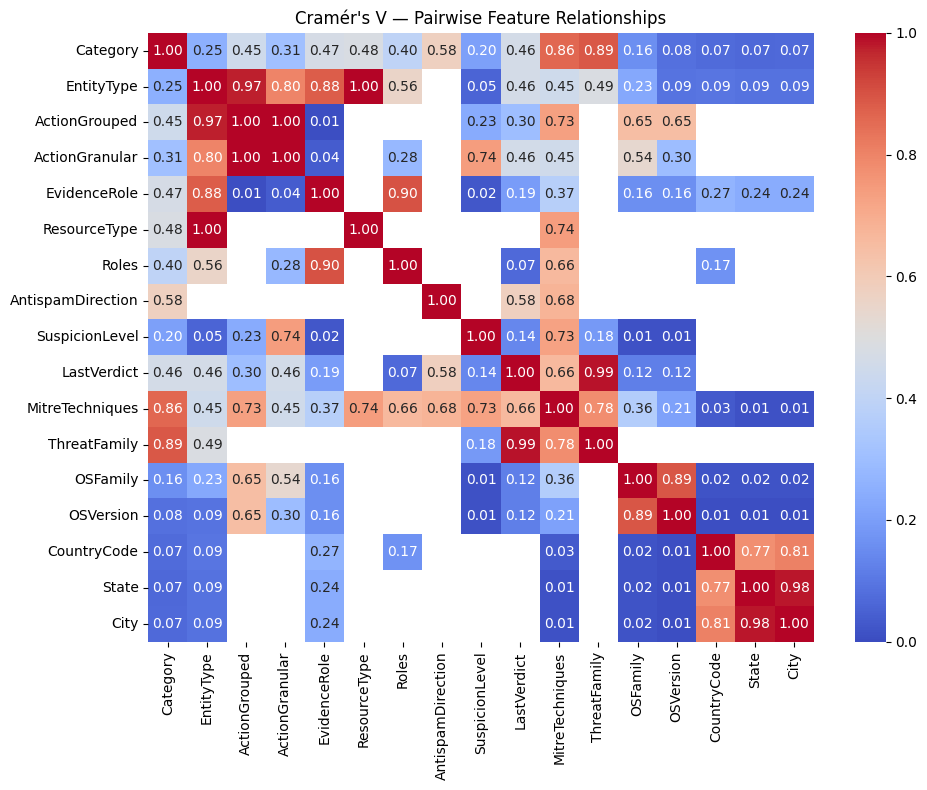

In [5]:
categorical_cols = ['Category', 'EntityType', 'ActionGrouped', 'ActionGranular',
                     'EvidenceRole', 'ResourceType', 'Roles', 'AntispamDirection',
                     'SuspicionLevel', 'LastVerdict', 'MitreTechniques', 'ThreatFamily',
                     'OSFamily', 'OSVersion', 'CountryCode', 'State', 'City']

# initialize an empty square matrix
matrix = pd.DataFrame(np.zeros((len(categorical_cols), len(categorical_cols))),
                       index=categorical_cols, columns=categorical_cols)

import warnings
warnings.filterwarnings('ignore')  # optional: silence the RuntimeWarnings visually

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            matrix.loc[col1, col2] = 1.0
        else:
            try:
                tab = pd.crosstab(df[col1], df[col2])
                matrix.loc[col1, col2] = association(tab, method='cramer')
            except ValueError:
                matrix.loc[col1, col2] = np.nan   # mark as "couldn't compute"
                
# # plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V — Pairwise Feature Relationships")
plt.tight_layout()
plt.show()

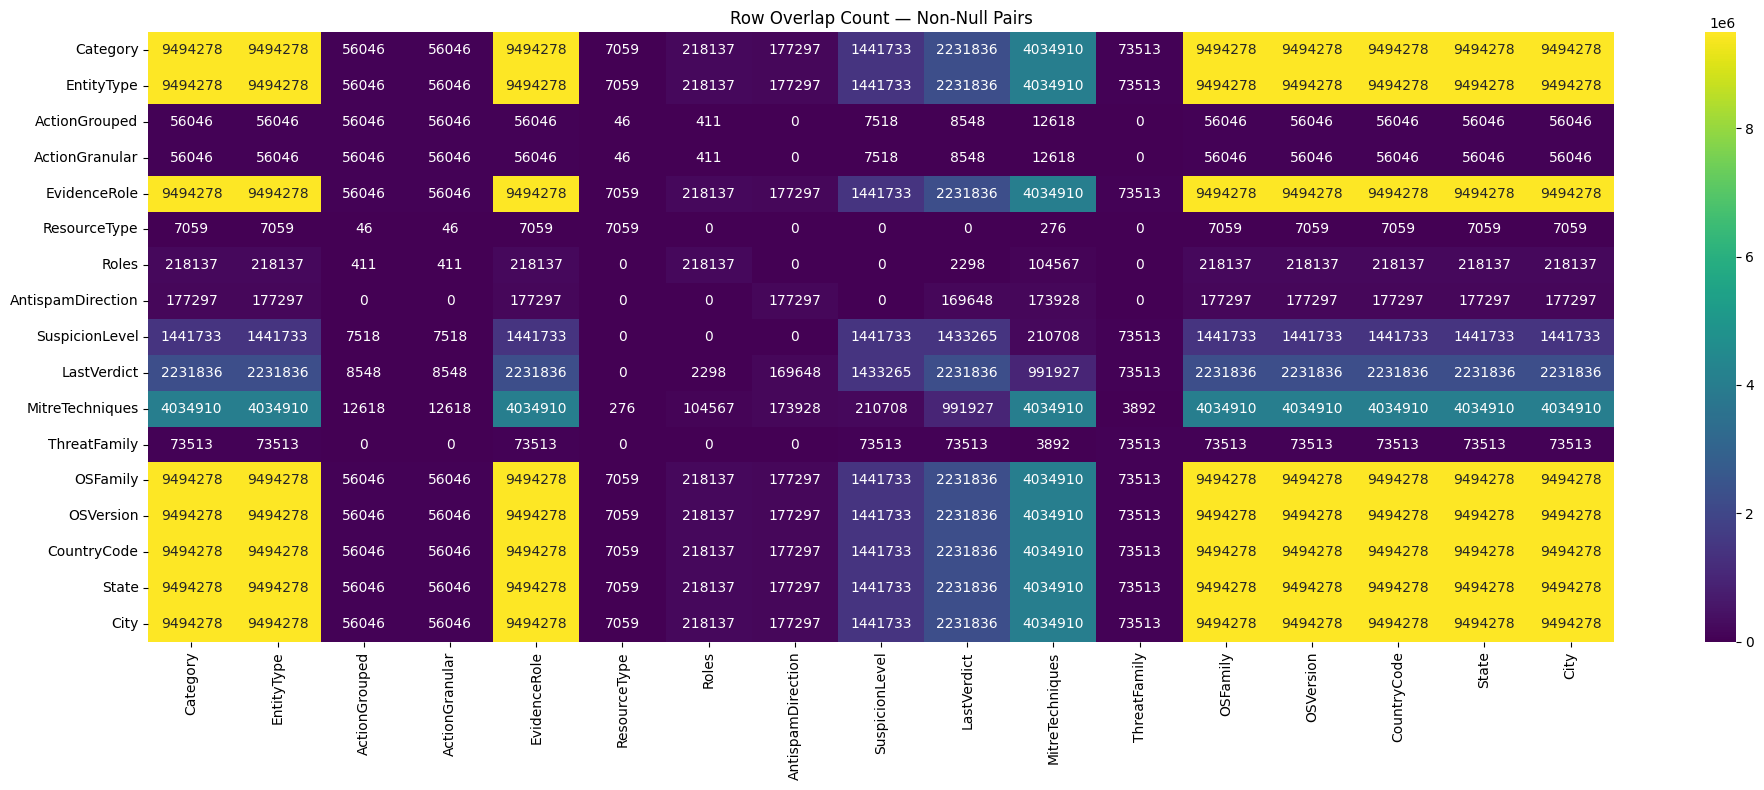

In [6]:
overlap_matrix = pd.DataFrame(np.zeros((len(categorical_cols), len(categorical_cols))),
                               index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        overlap_matrix.loc[col1, col2] = df[[col1, col2]].dropna().shape[0]
        
plt.figure(figsize=(20, 8))
sns.heatmap(overlap_matrix, annot=True, fmt='.0f', cmap='viridis')
plt.title("Row Overlap Count — Non-Null Pairs")
plt.tight_layout()
plt.show()

# Correlation & Redundancy Analysis Summary

## What was done

1. Computed **Cramér's V** between every categorical feature and the target (`IncidentGrade`) to rank features by predictive strength.
2. Computed **Cramér's V** between every pair of categorical features to check for redundancy between features themselves.
3. Computed **row-overlap counts** (non-null rows shared between each pair) to check whether those correlations were backed by enough data to be trustworthy.

## Key finding: correlation strength alone is misleading without checking overlap

All feature pairs with **Cramér's V ≥ 0.85**, along with their row overlap (non-null rows shared by both columns) and what share of the ~9.5M total rows that represents:

| Pair | Cramér's V | Row Overlap | % of Dataset |
|---|---|---|---|
| `EntityType` ↔ `ResourceType` | 1.00 | 7,059 | ~0.07% |
| `ActionGrouped` ↔ `ActionGranular` | 1.00 | 56,046 | ~0.6% |
| `LastVerdict` ↔ `ThreatFamily` | 0.99 | 3,892 | ~0.04% |
| `EntityType` ↔ `ActionGrouped` | 0.97 | 56,046 | ~0.6% |
| `EvidenceRole` ↔ `Roles` | 0.90 | 218,137 | ~2.3% |
| `Category` ↔ `ThreatFamily` | 0.89 | 73,513 | ~0.8% |
| `EntityType` ↔ `EvidenceRole` | 0.88 | 9,494,278 | ~99.9% |
| `Category` ↔ `MitreTechniques` | 0.86 | 4,034,910 | ~42.4% |

**Conclusion:** most of these near-perfect correlations are built on a **tiny fraction** of the dataset (well under 1% for most pairs), they're **nested/sparse relationships** that only exist for a small subset of specialized rows (e.g., cloud resources, or specific action-type alerts), not true redundancy. Since they rarely co-occur, keeping both costs little, and dropping either would lose information for that narrow slice of rows.

The two clear exceptions, with overlap large enough to be trustworthy, are `EntityType` ↔ `EvidenceRole` (99.9% coverage) and `Category` ↔ `MitreTechniques` (42.4% coverage) these are the pairs worth real scrutiny for redundancy.

In [7]:
df['EvidenceRole'].value_counts()

EvidenceRole
Related     5193267
Impacted    4301011
Name: count, dtype: int64

In [8]:
pd.crosstab(df['EntityType'], df['EvidenceRole'])

EvidenceRole,Impacted,Related
EntityType,,
ActiveDirectoryDomain,0,11
AmazonResource,6,0
AzureResource,8150,0
Blob,0,263
BlobContainer,0,306
CloudApplication,209785,7012
CloudLogonRequest,0,632503
CloudLogonSession,0,210556
Container,0,2


In [9]:
pd.crosstab(df['Category'], df['MitreTechniques'].notna())

MitreTechniques,False,True
Category,,
Collection,3705,11048
CommandAndControl,683006,143685
CredentialAccess,61642,236547
CredentialStealing,0,388
DefenseEvasion,17200,29454
Discovery,14850,114486
Execution,168802,98792
Exfiltration,1545464,32462
Exploit,4067,525


In [10]:
technique_sets = (
    df[df['MitreTechniques'].notna()]
    .assign(MitreTechniques=df['MitreTechniques'].str.split(';'))  # adjust delimiter as needed
    .explode('MitreTechniques')
    .groupby('Category')['MitreTechniques']
    .apply(set)
)

# pairwise Jaccard overlap between every category's technique set
import itertools
for a, b in itertools.combinations(technique_sets.index, 2):
    inter = len(technique_sets[a] & technique_sets[b])
    union = len(technique_sets[a] | technique_sets[b])
    jaccard = inter / union if union else 0
    print(a, b, round(jaccard, 3))

Collection CommandAndControl 0.044
Collection CredentialAccess 0.172
Collection CredentialStealing 0.02
Collection DefenseEvasion 0.043
Collection Discovery 0.176
Collection Execution 0.08
Collection Exfiltration 0.113
Collection Exploit 0.0
Collection Impact 0.014
Collection InitialAccess 0.06
Collection LateralMovement 0.083
Collection Malware 0.124
Collection Persistence 0.075
Collection PrivilegeEscalation 0.024
Collection Ransomware 0.056
Collection SuspiciousActivity 0.109
Collection UnwantedSoftware 0.0
Collection WebExploit 0.0
CommandAndControl CredentialAccess 0.148
CommandAndControl CredentialStealing 0.011
CommandAndControl DefenseEvasion 0.225
CommandAndControl Discovery 0.122
CommandAndControl Execution 0.234
CommandAndControl Exfiltration 0.108
CommandAndControl Exploit 0.048
CommandAndControl Impact 0.0
CommandAndControl InitialAccess 0.099
CommandAndControl LateralMovement 0.192
CommandAndControl Malware 0.176
CommandAndControl Persistence 0.087
CommandAndControl Privi

In [11]:
df[df['MitreTechniques'].notna()].groupby('Category')['MitreTechniques'].nunique()

Category
Collection              43
CommandAndControl       55
CredentialAccess       137
CredentialStealing       1
DefenseEvasion         134
Discovery              231
Execution              144
Exfiltration            28
Exploit                 12
Impact                  22
InitialAccess           51
LateralMovement        124
Malware                 84
Persistence            120
PrivilegeEscalation     40
Ransomware              23
SuspiciousActivity      90
UnwantedSoftware         5
WebExploit               1
Name: MitreTechniques, dtype: int64

## Pairs worth real scrutiny

### `EntityType` ↔ `EvidenceRole`

| Metric | Value |
|---|---|
| Cramér's V | 0.88 |
| Row Overlap | 9,494,278 (\~99.9% of dataset) |

This is the strongest pair with full coverage, so it's not a small-sample fluke.

The per-entity-type breakdown shows that most of the big entity types lean heavily one way: `Ip` (100% Related), `User` (\~99% Impacted), `MailCluster` (100% Related), `Mailbox` (\~98% Impacted), `Machine` (\~95% Impacted), `CloudLogonRequest` (100% Related), and `Url` (100% Related). Together they make up a large share of the rows. Only `File` (\~54/46) and `MailMessage` (\~58/42) are close to even, and while both are high-volume, they're a minority of the dataset. So the 0.88 reflects a real, broad pattern, not a handful of rare categories. `EvidenceRole` still adds something for `File` and `MailMessage`, but it's closer to "mostly determined by `EntityType`, with a couple of exceptions" than "largely independent."

### `Category` ↔ `MitreTechniques`

| Metric | Value |
|---|---|
| Cramér's V | 0.86 |
| Row Overlap | 4,034,910 (\~42.4% of dataset) |

Also backed by a big chunk of data, so it's worth asking whether `MitreTechniques` adds anything beyond `Category`.

Coverage is uneven: `MitreTechniques` is filled in for most rows in some categories (CredentialAccess 79%, Discovery 89%, InitialAccess 74%) and almost never in others (Exfiltration, Impact, SuspiciousActivity, all around 2%). That alone explains part of the high correlation. Where the column is present, though, there's real variety. Looking at individual technique IDs rather than whole multi-technique strings, Discovery alone covers 231 distinct techniques, with Execution (144), CredentialAccess (137), LateralMovement (124), and Persistence (120) also spread wide. Pairwise Jaccard similarity between categories' technique sets is mostly low (many pairs near 0, e.g. `CredentialStealing` vs. almost everything), with a few moderate overlaps around 0.25 to 0.32 (`Execution`↔`Malware`, `CredentialAccess`↔`LateralMovement`) that plausibly reflect attack chains spanning multiple tactics.

**Caveat:** the Jaccard check is suggestive, not conclusive. It shows categories don't share identical technique vocabularies, which argues against full redundancy, but it doesn't tell us whether `MitreTechniques` actually improves predictions. That's deferred to modeling (see Decision below).

### `CountryCode` ↔ `State` ↔ `City`

| Pair | Cramér's V |
|---|---|
| `State` ↔ `City` | 0.98 |
| `CountryCode` ↔ `City` | 0.81 |
| `CountryCode` ↔ `State` | 0.77 |

All three columns are populated on every row, so there's no missing-data caveat here. This is the expected hierarchy: city implies state implies country. `State` ↔ `City` at 0.98 is near-total duplication.

**Proposed reduction: keep `CountryCode`, drop `State` and `City`.** It's not just "pick one." `City` (9,342 unique values) and `State` (1,368) are far higher cardinality than `CountryCode` (236), which bloats encoding and generalizes badly to values barely seen in training. `CountryCode` keeps most of the signal at a fraction of the cardinality. Still a candidate for ablation, not a final drop.

### `OSFamily` ↔ `OSVersion`

| Metric | Value |
|---|---|
| Cramér's V | 0.89 |
| Row Overlap | 9,494,278 (100% of dataset) |

Weaker redundancy than the geography cluster, and tangled up with an open data-quality question. The cleaning notebook found `OSVersion`'s dominant value in \~72.3% of `Machine` rows, the one entity type where OS version actually means something. That's too high to confirm as a clean "not applicable" sentinel (the 15 confirmed sentinel columns were near-zero at their relevant entity type) but too concentrated to rule out. It was left unmodified in cleaning.

**No reduction proposed.** Dropping `OSVersion` now would stack a permanent decision on top of an unresolved one (is `66` real or fake). Both columns stay as-is, flagged for ablation, and revisited if the sentinel question gets settled.

## Decision so far

**Nothing has been dropped yet.** Every high-correlation pair has either a plausible case for real signal or an open data-quality question:

- `EntityType` ↔ `EvidenceRole`: real signal, but weaker than it first looked. **Keep, test via ablation.**
- `Category` ↔ `MitreTechniques`: genuine per-category technique diversity, low Jaccard across most pairs. **Keep, test via ablation.**
- `State` / `City` vs. `CountryCode`: near-total, expected geographic redundancy with full coverage. **Candidate to drop `State`/`City`, keep `CountryCode`.** The strongest EDA case for a drop, but still confirmed via ablation first.
- `OSFamily` ↔ `OSVersion`: weaker correlation, entangled with the `OSVersion` sentinel question. **No decision. Flagged, revisit after ablation or sentinel resolution.**

**Plan:** keep all flagged columns going into modeling. Run the model with and without each flagged column or cluster (`EvidenceRole`, `MitreTechniques`, `State`+`City` vs. `CountryCode` only, `OSVersion`) and see if performance moves. That comparison, not the association metrics, makes the final call.

In [12]:
df.to_csv('/kaggle/working/GUIDE_Train_post_cat_eda.csv', index=False)